# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler


from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,r2_score,roc_auc_score,RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score





# Reading & Reshaping The Data

In [2]:
df_full = pd.read_csv("creditcard.csv")

sample_size = 15000
fraud_ratio = 0.03
fraud_count = int(sample_size * fraud_ratio)
normal_count = sample_size - fraud_count
random_state = 42

fraud_sample = df_full[df_full["Class"] == 1].sample(
    n=fraud_count,
    replace=fraud_count > (df_full["Class"] == 1).sum(),
    random_state=random_state
)
normal_sample = df_full[df_full["Class"] == 0].sample(n=normal_count, random_state=random_state)

df = pd.concat([fraud_sample, normal_sample], ignore_index=True)
df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

print(df.shape)
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

(15000, 31)
Class
0    14550
1      450
Name: count, dtype: int64
Class
0    97.0
1     3.0
Name: proportion, dtype: float64


# Data Investigation

In [3]:
df.shape

(15000, 31)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    15000 non-null  float64
 1   V1      15000 non-null  float64
 2   V2      15000 non-null  float64
 3   V3      15000 non-null  float64
 4   V4      15000 non-null  float64
 5   V5      15000 non-null  float64
 6   V6      15000 non-null  float64
 7   V7      15000 non-null  float64
 8   V8      15000 non-null  float64
 9   V9      15000 non-null  float64
 10  V10     15000 non-null  float64
 11  V11     15000 non-null  float64
 12  V12     15000 non-null  float64
 13  V13     15000 non-null  float64
 14  V14     15000 non-null  float64
 15  V15     15000 non-null  float64
 16  V16     15000 non-null  float64
 17  V17     15000 non-null  float64
 18  V18     15000 non-null  float64
 19  V19     15000 non-null  float64
 20  V20     15000 non-null  float64
 21  V21     15000 non-null  float64
 22  V22     1

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,94685.601467,-0.127226,0.105085,-0.216090,0.123470,-0.074528,-0.046353,-0.169445,0.023412,-0.056573,...,0.018872,0.001349,-0.001416,-0.005875,-0.006784,0.003314,0.005480,0.003711,87.513799,0.030000
std,47472.681430,2.358191,1.839971,2.227167,1.652035,1.690446,1.362707,1.926509,1.627986,1.249462,...,0.980881,0.755245,0.646074,0.610759,0.531213,0.483708,0.461721,0.342022,227.313623,0.170593
min,0.000000,-30.552380,-32.494845,-31.103685,-4.938824,-22.105532,-17.282140,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.836627,-4.781606,-1.581931,-9.543518,-8.307955,0.000000,0.000000
25%,54409.750000,-0.954512,-0.586813,-1.018264,-0.816403,-0.708259,-0.799760,-0.604359,-0.204568,-0.675899,...,-0.223291,-0.545677,-0.165963,-0.356566,-0.324105,-0.327020,-0.069713,-0.052208,4.990000,0.000000
50%,84976.500000,-0.003432,0.087175,0.116673,0.021128,-0.061710,-0.294764,0.019296,0.026491,-0.056026,...,-0.022551,0.009803,-0.010047,0.036833,0.012000,-0.042159,0.003236,0.011971,21.000000,0.000000
75%,139139.500000,1.303224,0.860411,0.985389,0.825526,0.629130,0.386568,0.569782,0.350819,0.600701,...,0.195462,0.527567,0.154336,0.433143,0.348877,0.253821,0.099948,0.082582,76.442500,0.000000
max,172768.000000,2.398119,22.057729,3.770236,11.906170,28.516513,15.323769,15.915767,20.007208,7.929051,...,27.202839,8.361985,15.626067,4.016342,5.541598,3.039297,9.879903,15.870474,6511.000000,1.000000


In [6]:
df.duplicated().sum()

np.int64(20)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
for col in df.columns:
    print(df[col].value_counts())

Time
48601.0     5
41273.0     3
146998.0    3
37187.0     3
93879.0     3
           ..
81579.0     1
137908.0    1
22396.0     1
167609.0    1
39737.0     1
Name: count, Length: 14229, dtype: int64
V1
 2.055797    7
 1.245674    5
 2.085175    3
 1.302378    3
 1.012595    3
            ..
 1.519406    1
 1.378933    1
-0.199324    1
-1.078759    1
 1.099987    1
Name: count, Length: 14923, dtype: int64
V2
-0.326668    7
 0.166975    5
 0.393051    3
-0.606529    3
 0.185411    3
            ..
-0.931312    1
-0.411443    1
 1.170036    1
 0.257122    1
-0.233236    1
Name: count, Length: 14923, dtype: int64
V3
-2.752041    7
 0.488306    5
-4.508201    3
-0.681986    3
 1.857002    3
            ..
-0.818590    1
 0.679079    1
-0.202227    1
 0.961346    1
 1.117423    1
Name: count, Length: 14923, dtype: int64
V4
-0.842316    7
 0.635322    5
-0.311771    3
-1.904603    3
 2.625675    3
            ..
 1.169195    1
-0.508045    1
-0.574850    1
-0.753251    1
 0.684984    1
Name:

# Data Visualization 

<function matplotlib.pyplot.show(close=None, block=None)>

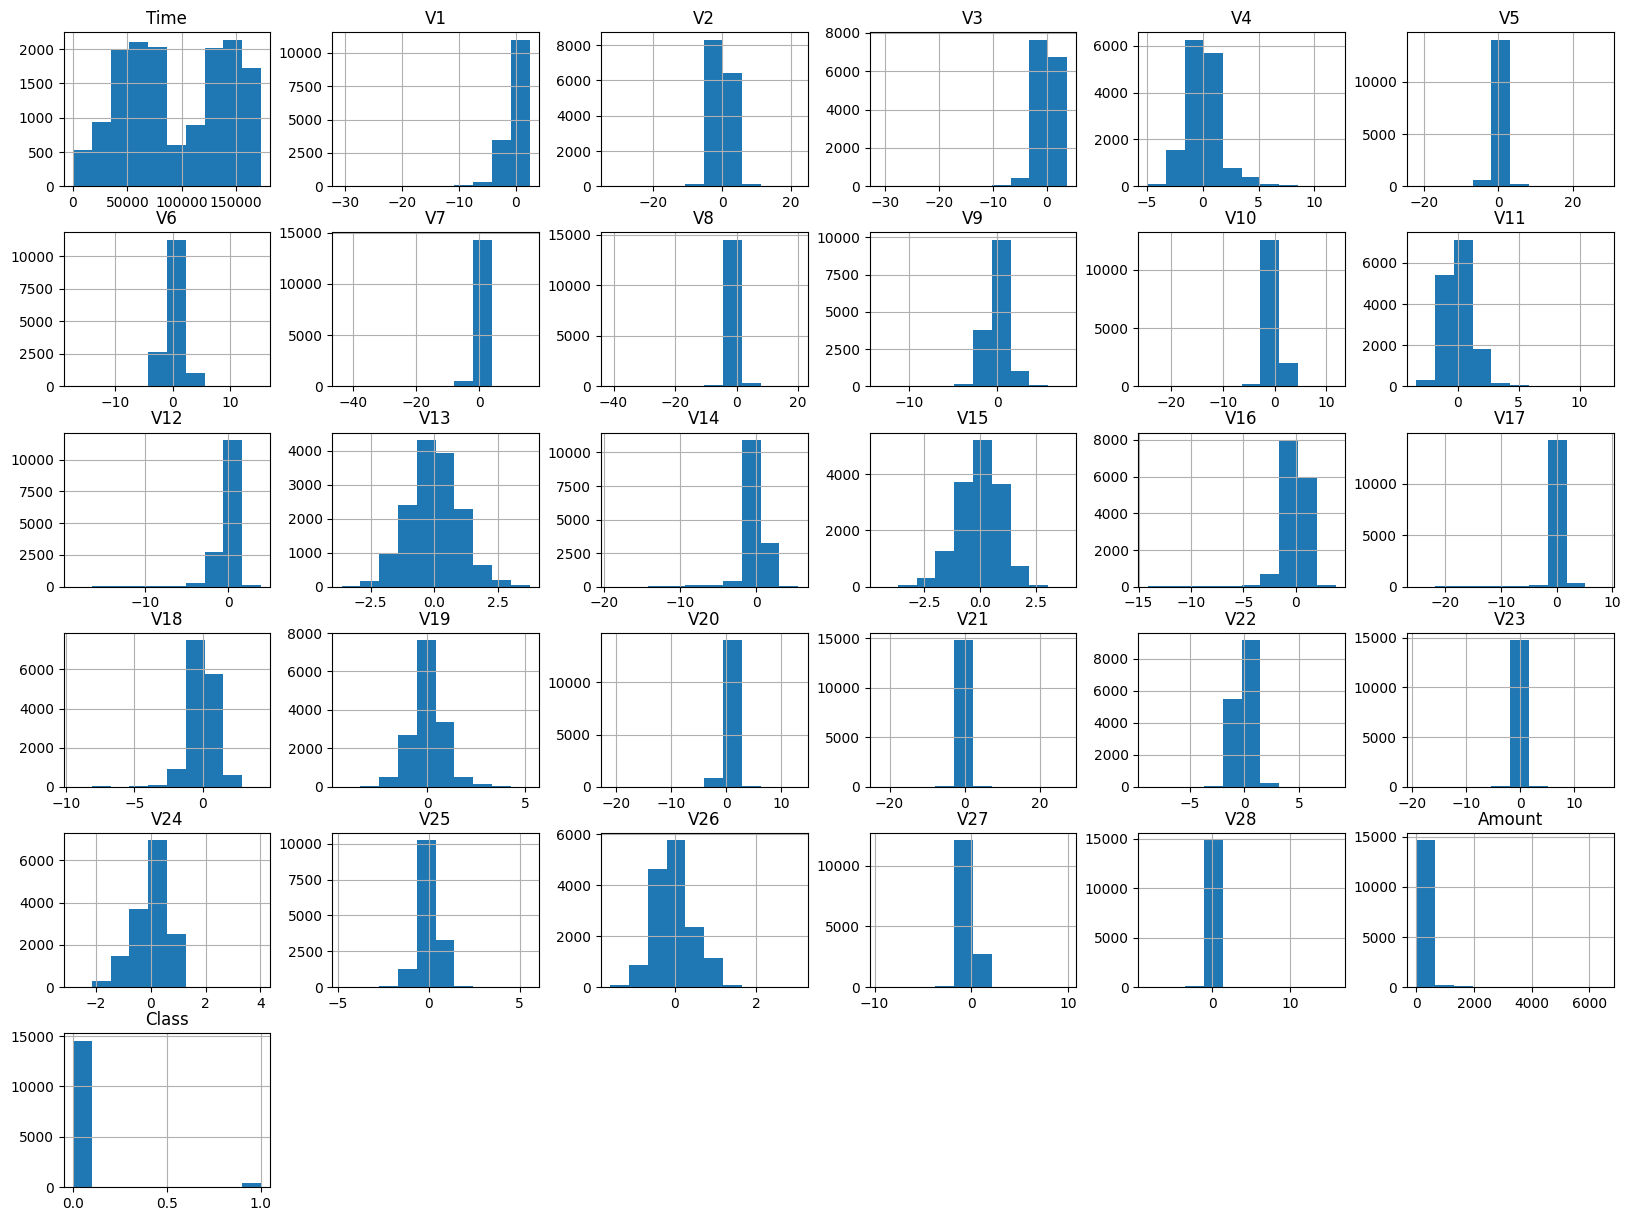

In [11]:
df.hist(figsize=(20,15))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

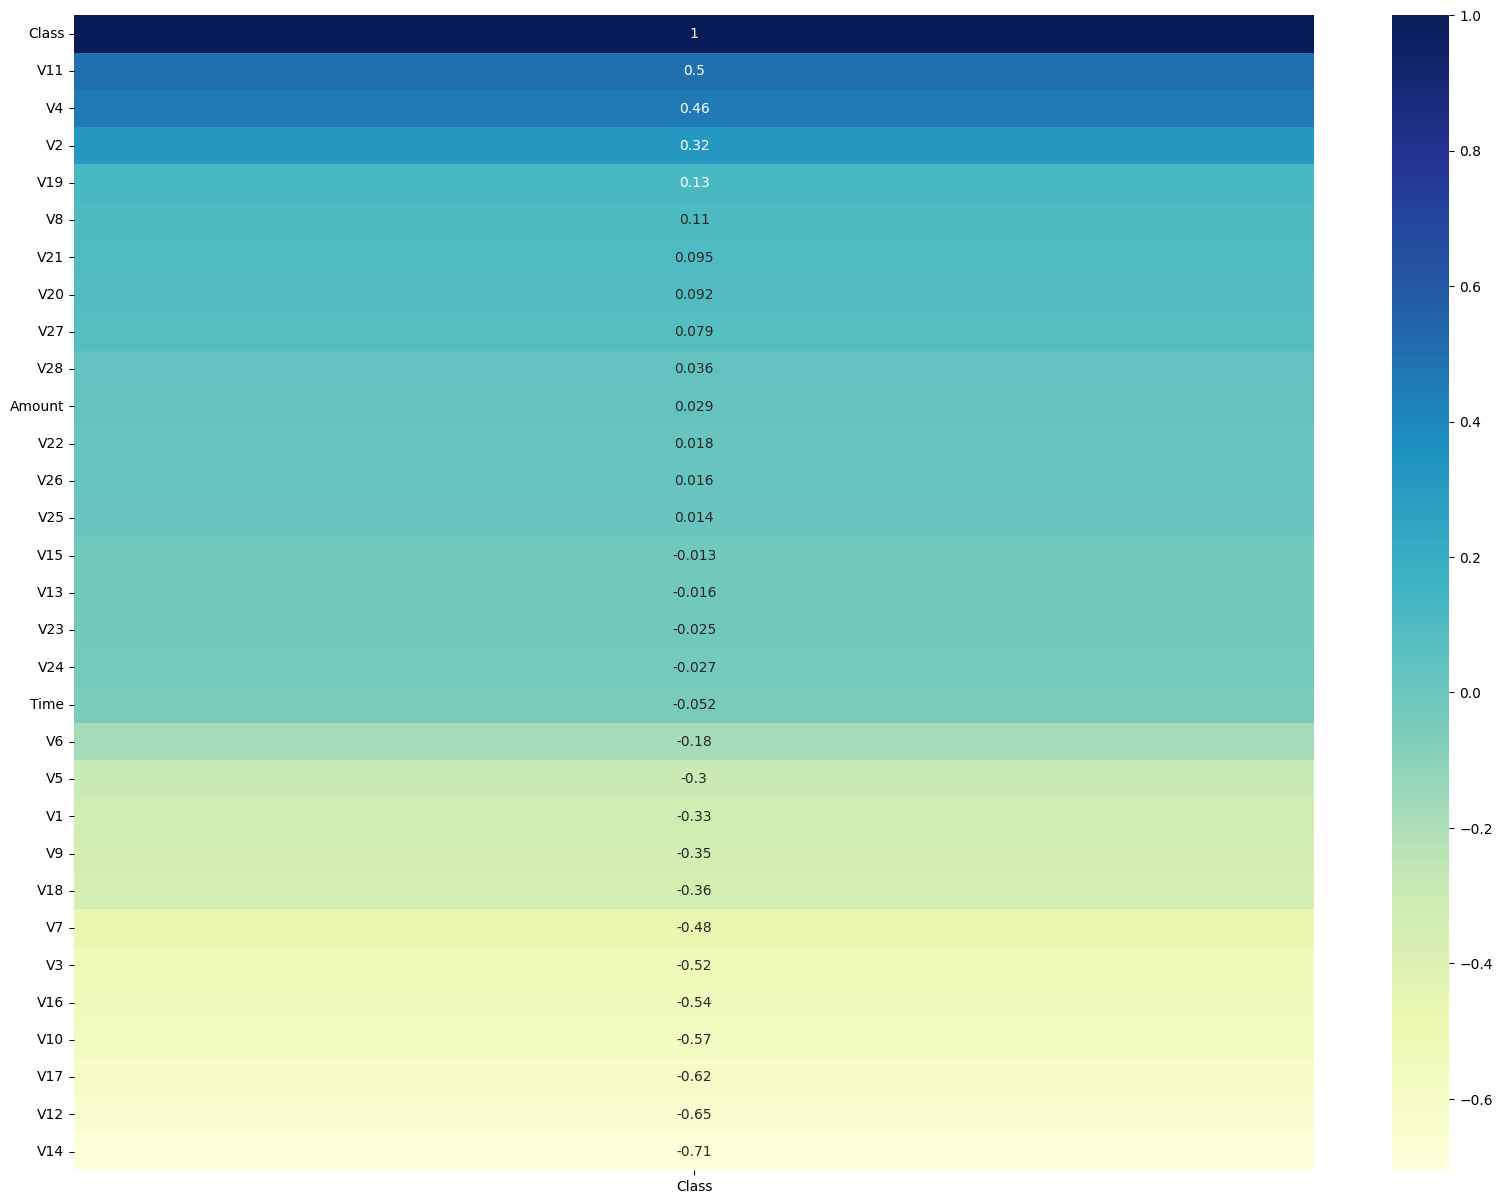

In [12]:
plt.figure(figsize=(20,15))
corr = df.corr()
labaled_corr = corr[["Class"]].sort_values("Class",ascending=False)
sns.heatmap(labaled_corr,annot=True,cmap="YlGnBu")
plt.show

In [13]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [14]:
df= df.drop([ 'V13', 'V15', 'V22', 'V23', 'V25', 'V26'],axis=1)

In [15]:
df["Class"].isnull().sum()

np.int64(0)

# Checking for outliers in the "Amount" col.

In [16]:
q1 = df["Amount"].quantile(0.25)
q3 = df["Amount"].quantile(0.75)

iqr = q3-q1
upper = q3+1.5*iqr
lower = q1-1.5*iqr
outliers = ((df["Amount"]<lower)|(df["Amount"]>upper))
num_outlier = outliers.sum()
print("number of outlier rows : ",num_outlier)
print("the percentage of the outlier rows : ",num_outlier/len(df))

number of outlier rows :  1707
the percentage of the outlier rows :  0.11395193591455274


In [17]:
df["Amount"].describe()

count    14980.000000
mean        87.531432
std        227.411517
min          0.000000
25%          5.000000
50%         21.005000
75%         76.442500
max       6511.000000
Name: Amount, dtype: float64

# Splitting The Data

In [18]:
x = df.drop(columns = "Class")
y = df["Class"]

In [19]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state = 42

)

In [20]:
x_train = pd.DataFrame(x_train,columns=x.columns)
x_test = pd.DataFrame(x_test,columns=x.columns)

In [21]:
x_train.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V24',
       'V27', 'V28', 'Amount'],
      dtype='str')

In [22]:
x_test.shape

(3745, 24)

In [23]:
y_train.value_counts()

Class
0    10911
1      324
Name: count, dtype: int64

In [24]:
y_test.value_counts()

Class
0    3637
1     108
Name: count, dtype: int64

# Capping the outliers in the "Amount"

In [25]:
q1 = x_train['Amount'].quantile(0.25)
q3 = x_train['Amount'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

x_train['Amount'] = x_train['Amount'].clip(lower=lower_fence, upper=upper_fence)
x_test['Amount'] = x_test['Amount'].clip(lower=lower_fence, upper=upper_fence)

In [26]:
x_train["Amount"].describe()

count    11235.000000
mean        51.191926
std         61.435106
min          0.000000
25%          5.000000
50%         21.000000
75%         76.370000
max        183.425000
Name: Amount, dtype: float64

In [27]:
x_test["Amount"].describe()

count    3745.000000
mean       51.635686
std        62.159449
min         0.000000
25%         4.940000
50%        21.090000
75%        77.050000
max       183.425000
Name: Amount, dtype: float64

# Applying Standardization for "Time" & "Amount" 

In [28]:

scaler_amount = StandardScaler()
scaler_time = StandardScaler()


x_train['scaled_amount'] = scaler_amount.fit_transform(x_train[['Amount']])
x_train['scaled_time'] = scaler_time.fit_transform(x_train[['Time']])

x_test['scaled_amount'] = scaler_amount.transform(x_test[['Amount']])
x_test['scaled_time'] = scaler_time.transform(x_test[['Time']])

# SVC Model

In [29]:
svc = SVC(kernel='sigmoid',C=1,degree=3,random_state=42,probability=True)
svc.fit(x_train,y_train)

C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [30]:
svc_pred = svc.predict(x_test)
svc_pred_train = svc.predict(x_train)
svc_pred_proba = svc.predict_proba(x_test)[:, 1]


# checking overfitting

In [31]:
print("model accuracy",accuracy_score(y_test, svc_pred))
print("train accuracy",accuracy_score(y_train, svc_pred_train))

model accuracy 0.9711615487316422
train accuracy 0.9711615487316422


In [32]:
print("Classification Report \n",classification_report(y_test,svc_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3637
           1       0.00      0.00      0.00       108

    accuracy                           0.97      3745
   macro avg       0.49      0.50      0.49      3745
weighted avg       0.94      0.97      0.96      3745



C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [33]:
print("R2 Score: ",r2_score(y_test,svc_pred))

R2 Score:  -0.029694803409403336


In [34]:
print("ROC-AUC: ",roc_auc_score(y_test,svc_pred_proba))

ROC-AUC:  0.5321668245094145


In [35]:
print("Confusion Matrix\n",confusion_matrix(y_test,svc_pred))

Confusion Matrix
 [[3637    0]
 [ 108    0]]


# Grid Search

In [ ]:
param ={'kernel':['sigmoid','rbf','poly'],'C':[0.1,1,4],'degree':[2,3,4],'random_state':[42]}
grid = GridSearchCV(SVC(),param)
grid.fit(x_train,y_train)

In [ ]:
grid.best_params_

{'C': 0.1, 'degree': 2, 'kernel': 'sigmoid', 'random_state': 42}

In [ ]:
grid.best_score_

np.float64(0.9711615487316422)

# Logistic Regression Model

In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(x_train,y_train)

C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
logistic_pred__train = logistic_model.predict(x_train)

In [ ]:
logistic_pred = logistic_model.predict(x_test)

In [ ]:
logistic_pred_proba = logistic_model.predict_proba(x_test)[:, 1]

# checking overfitting

In [ ]:
print("Model Accuracy :", accuracy_score(y_test, logistic_pred))
print("Train Accuracy :", accuracy_score(y_train,logistic_pred__train ))

Model Accuracy : 0.9949265687583445
Train Accuracy : 0.9935914552736983


In [ ]:
print("Classification Report \n",classification_report(y_test,logistic_pred))

Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       0.98      0.84      0.91       108

    accuracy                           0.99      3745
   macro avg       0.99      0.92      0.95      3745
weighted avg       0.99      0.99      0.99      3745



In [ ]:
print("R2 Score: ",r2_score(y_test,logistic_pred))

R2 Score:  0.8188499882890865


In [ ]:
print("ROC-AUC: ",roc_auc_score(y_test,logistic_pred_proba))

ROC-AUC:  0.9593173046568703


In [ ]:
print("Confusion Matrix\n",confusion_matrix(y_test,logistic_pred))

Confusion Matrix
 [[3635    2]
 [  17   91]]


# KNN

In [ ]:
knn= KNeighborsClassifier(n_neighbors=2,weights="distance")
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
knn_pred = knn.predict(x_test)

In [ ]:
knn_train = knn.predict(x_train)

In [ ]:
knn_pred_proba = knn.predict_proba(x_test)[:, 1]

# Checking overfitting

In [ ]:
print("model accuracy :",accuracy_score(y_test,knn_pred))
print("train accuracy :",accuracy_score(y_train,knn_train))

model accuracy : 0.9580774365821095
train accuracy : 1.0


In [ ]:
print("classification Report : \n",classification_report(y_test,knn_pred))

classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3637
           1       0.24      0.21      0.23       108

    accuracy                           0.96      3745
   macro avg       0.61      0.60      0.60      3745
weighted avg       0.96      0.96      0.96      3745



In [ ]:
print("R2 Score: ",r2_score(y_test,knn_pred))

R2 Score:  -0.49687114940070654


In [ ]:
print("ROC-AUC: ",roc_auc_score(y_test,knn_pred_proba))

ROC-AUC:  0.6076640291652665


In [ ]:
print("confusion matrix : \n",confusion_matrix(y_test,knn_pred))


confusion matrix : 
 [[3565   72]
 [  85   23]]


# Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
dt_pred = dt.predict(x_test)

In [ ]:
dt_train = dt.predict(x_train)

In [ ]:
dt_pred_proba = dt.predict_proba(x_test)[:, 1]

# Checking overfitting

In [ ]:
print("model accuracy :",accuracy_score(y_test,dt_pred))
print("train accuracy :",accuracy_score(y_train,dt_train))

model accuracy : 0.9890520694259012
train accuracy : 1.0


In [ ]:
print("classification Report : \n",classification_report(y_test,dt_pred))

classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3637
           1       0.77      0.88      0.82       108

    accuracy                           0.99      3745
   macro avg       0.88      0.94      0.91      3745
weighted avg       0.99      0.99      0.99      3745



In [ ]:
print("R2 Score: ",r2_score(y_test,dt_pred))

R2 Score:  0.609097343150134


In [ ]:
print("ROC-AUC: ",roc_auc_score(y_test,dt_pred_proba))

ROC-AUC:  0.9359654884469294


In [ ]:
print("confusion matrix : \n",confusion_matrix(y_test,dt_pred))


confusion matrix : 
 [[3609   28]
 [  13   95]]


# Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
rf_pred = rf.predict(x_test)

In [ ]:
rf_train = rf.predict(x_train)

In [ ]:
rf_pred_proba = rf.predict_proba(x_test)[:, 1]

# Checking overfitting

In [ ]:
print("model accuracy :",accuracy_score(y_test,rf_pred))
print("train accuracy :",accuracy_score(y_train,rf_train))

model accuracy : 0.9959946595460614
train accuracy : 0.9999109924343569


In [ ]:
print("classification Report : \n",classification_report(y_test,rf_pred))

classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       0.98      0.88      0.93       108

    accuracy                           1.00      3745
   macro avg       0.99      0.94      0.96      3745
weighted avg       1.00      1.00      1.00      3745



In [ ]:
print("R2 Score: ",r2_score(y_test,rf_pred))

R2 Score:  0.8569868328598051


In [ ]:
print("ROC-AUC: ",roc_auc_score(y_test,rf_pred_proba))

ROC-AUC:  0.9697107404352387


In [ ]:
print("confusion matrix : \n",confusion_matrix(y_test,rf_pred))


confusion matrix : 
 [[3635    2]
 [  13   95]]


# Extra Tree

In [ ]:
et = ExtraTreesClassifier(n_estimators=150,random_state=42)
et.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` 

In [ ]:
et_pred = et.predict(x_test)

In [ ]:
et_train = et.predict(x_train)

In [ ]:
et_pred_proba = et.predict_proba(x_test)[:, 1]

# Checking overfitting

In [ ]:
print("model accuracy :",accuracy_score(y_test,et_pred))
print("train accuracy :",accuracy_score(y_train,et_train))

model accuracy : 0.9959946595460614
train accuracy : 1.0


In [ ]:
print("classification Report : \n",classification_report(y_test,et_pred))

classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3637
           1       0.98      0.88      0.93       108

    accuracy                           1.00      3745
   macro avg       0.99      0.94      0.96      3745
weighted avg       1.00      1.00      1.00      3745



In [ ]:
print("R2 Score: ",r2_score(y_test,et_pred))

R2 Score:  0.8569868328598051


In [ ]:
print("ROC-AUC: ",roc_auc_score(y_test,et_pred_proba))

ROC-AUC:  0.9730789010071386


In [ ]:
print("confusion matrix : \n",confusion_matrix(y_test,et_pred))


confusion matrix : 
 [[3635    2]
 [  13   95]]


# Models Comparison

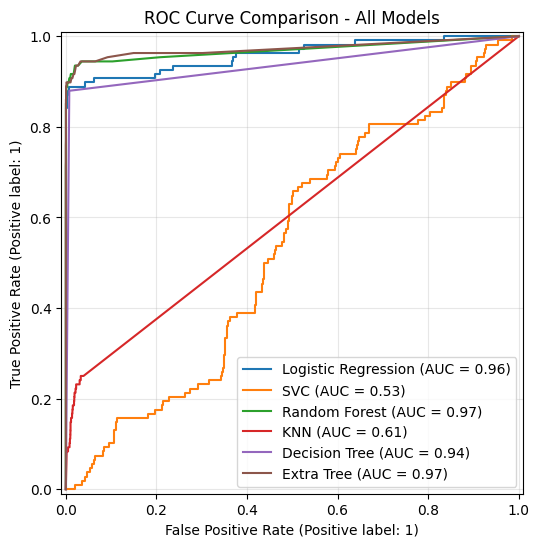

In [ ]:
predictions = {
    'Logistic Regression': logistic_pred_proba,
    'SVC': svc_pred_proba,
    'Random Forest': rf_pred_proba,
    'KNN': knn_pred_proba,
    'Decision Tree': dt_pred_proba,
    'Extra Tree': et_pred_proba
}

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in predictions.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)

plt.title('ROC Curve Comparison - All Models')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
models_results = {
    'SVC': {'pred': svc_pred, 'train_pred': svc_pred_train, 'proba': svc_pred_proba},
    'Logistic Regression': {'pred': logistic_pred, 'train_pred': logistic_pred__train, 'proba': logistic_pred_proba},
    'KNN': {'pred': knn_pred, 'train_pred': knn_train, 'proba': knn_pred_proba},
    'Decision Tree': {'pred': dt_pred, 'train_pred': dt_train, 'proba': dt_pred_proba},
    'Random Forest': {'pred': rf_pred, 'train_pred': rf_train, 'proba': rf_pred_proba},
    'Extra Tree': {'pred': et_pred, 'train_pred': et_train, 'proba': et_pred_proba}
}
comparison = []
for name, res in models_results.items():
    test_acc = accuracy_score(y_test, res['pred'])
    train_acc = accuracy_score(y_train, res['train_pred'])
    precision = precision_score(y_test, res['pred'])
    recall = recall_score(y_test, res['pred'])
    f1 = f1_score(y_test, res['pred'])
    r2 = r2_score(y_test, res['pred'])
    roc_auc = roc_auc_score(y_test, res['proba'])
    overfit_gap = train_acc - test_acc

    comparison.append({
        'Model': name,
        'Test Accuracy': test_acc,
        'Train Accuracy': train_acc,
        'Overfitting Gap': overfit_gap,
        'Precision (Fraud)': precision,
        'Recall (Fraud)': recall,
        'F1-Score (Fraud)': f1,
        'R2 Score': r2,
        'ROC-AUC': roc_auc
    })
comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
comparison_df

C:\Users\Mahmoud\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Test Accuracy,Train Accuracy,Overfitting Gap,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),R2 Score,ROC-AUC
0,Extra Tree,0.995995,1.000000,0.004005,0.979381,0.879630,0.926829,0.856987,0.973079
1,Random Forest,0.995995,0.999911,0.003916,0.979381,0.879630,0.926829,0.856987,0.969711
2,Logistic Regression,0.994927,0.993591,-0.001335,0.978495,0.842593,0.905473,0.818850,0.959317
3,Decision Tree,0.989052,1.000000,0.010948,0.772358,0.879630,0.822511,0.609097,0.935965
4,KNN,0.958077,1.000000,0.041923,0.242105,0.212963,0.226601,-0.496871,0.607664
5,SVC,0.971162,0.971162,0.000000,0.000000,0.000000,0.000000,-0.029695,0.532167


<function matplotlib.pyplot.show(close=None, block=None)>

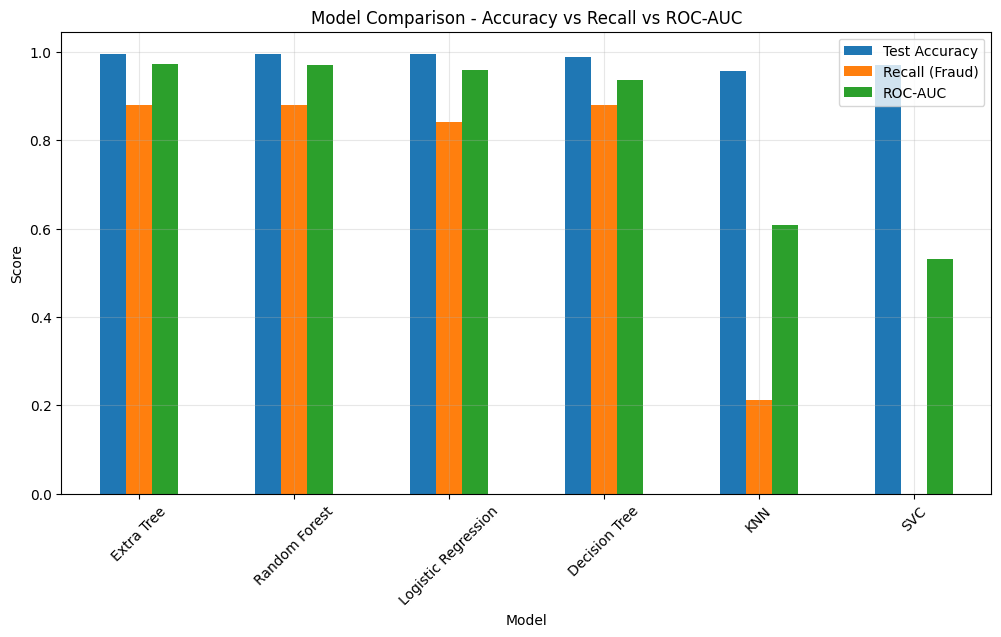

In [ ]:
# visualizing the comparison

comparison_df.set_index('Model')[['Test Accuracy', 'Recall (Fraud)', 'ROC-AUC']].plot(
    kind='bar', figsize=(12,6)
)
plt.title('Model Comparison - Accuracy vs Recall vs ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show